In [169]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import pandas as pd
import seaborn as sns
import scipy.optimize as opt

In [123]:
hdffiles = []
for path, dirs, files in os.walk("data"):
    if len(files) == 2:
        name = path.split("\\")[-1]
        name = "-".join(name.split("-")[4:])
        data = h5py.File(path + "/dataset.hdf5", "r")
        fields = {}
        for key in data.keys():
            if "units" in data[key].attrs:
                fieldname = data[key].attrs["long_name"] + " (" + data[key].attrs["units"] + ")"
                fields[fieldname] = data[key]
            else:
                # print("No units for "   + key)
                pass
                # fieldname = "dim_0"
            
        hdffiles.append([name, pd.DataFrame(data=fields)])

In [138]:
for (i, (name, df)) in enumerate(hdffiles):
    props = []
    for col in df.keys():
        props.append(col)
    print(f'{i:<5}', name, props)

0     Resonator spectroscopy VNA (power=0 dBm) ['freq_index (#)', 'S21 real (ratio)', 'S21 imag (ratio)']
1     Resonator spectroscopy VNA (power=0 dBm) ['VNA sweep frequency (Hz)', 'S21 real (ratio)', 'S21 imag (ratio)', 'freq_index (#)']
2     Resonator spectroscopy VNA (power=0 dBm) ['VNA sweep frequency (Hz)', 'S21 real (ratio)', 'S21 imag (ratio)', 'freq_index (#)']
3     Punchout VNA (6.8489-6.8589 GHz) ['vna Power (dBm)', 'VNA sweep frequency (Hz)', 'S21 real (ratio)', 'S21 imag (ratio)', 'freq_index (#)', 'magnitude']
4     Punchout VNA (6.8529-6.8549 GHz) ['vna Power (dBm)', 'freq_index (#)', 'S21 real (ratio)', 'S21 imag (ratio)']
5     Punchout VNA (6.8534-6.8554 GHz) ['vna Power (dBm)', 'VNA sweep frequency (Hz)', 'S21 real (ratio)', 'S21 imag (ratio)', 'freq_index (#)']
6     Punchout VNA (6.8534-6.8554 GHz) ['vna Power (dBm)', 'VNA sweep frequency (Hz)', 'S21 real (ratio)', 'S21 imag (ratio)', 'freq_index (#)']
7     Punchout VNA (6.8534-6.8554 GHz) ['vna Power (dBm)', 'V

In [131]:
# hdffiles[0][1].keys()
#Index(['freq_index (#)', 'S21 real (ratio)', 'S21 imag (ratio)'], dtype='str')

from matplotlib.ticker import FormatStrFormatter
from matplotlib import ticker

def nice_hm(data, title, invert_y=False):
    data = data.copy()

    data.index = data.index.map(lambda x: f"{x:.5g}")
    data.columns = data.columns.map(lambda x: f"{x:.5g}")
    ax = sns.heatmap(data=data)
    ax.set_title(title)
    if invert_y:
        ax.invert_yaxis()

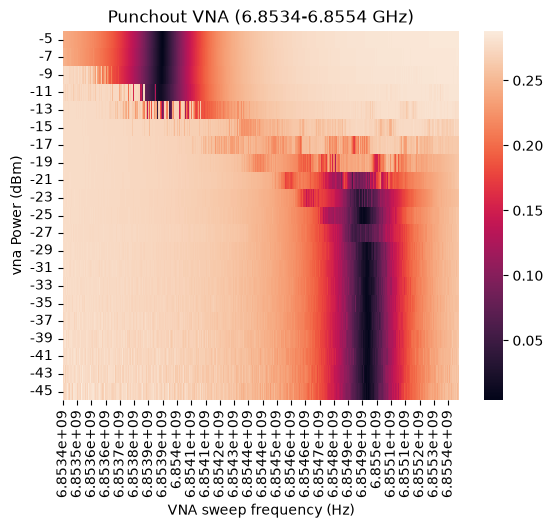

In [132]:
d = hdffiles[7][1]
magnitude = np.sqrt(d["S21 real (ratio)"]**2 + d["S21 imag (ratio)"]**2)
d["magnitude"] = magnitude
data = d.pivot_table(columns="VNA sweep frequency (Hz)", index="vna Power (dBm)", values="magnitude")
nice_hm(data, hdffiles[7][0], True)

Optimization terminated successfully.
         Current function value: 0.000002
         Iterations: 60
         Function evaluations: 115
t_1 4.9450293902219804e-05
t_2 3.406758354460626e-05


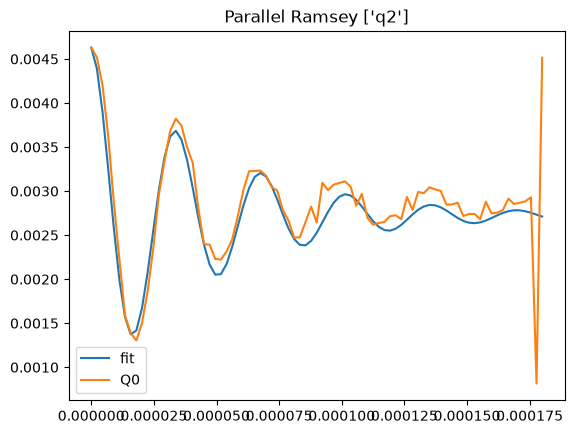

In [224]:
d = hdffiles[63][1]
# 'Decay time (s)', 'Voltage I0 (V)', 'Voltage Q0 (V)'
t = d["Decay time (s)"]
Q0 = d["Voltage Q0 (V)"]
I0 = d["Voltage I0 (V)"]

Q0_max = Q0.max()
Q0_min = Q0.min()

t_1 = 0.00005
t_2 = 1/0.00003

def model(args):
    return (np.exp(-t/args[0]) * np.cos(2*np.pi*t*args[1])/2 + 0.5) * (Q0_max - Q0_min) + Q0_min

def optfunc(args):
    return np.sum((model(args)[:-3] - Q0[:-3])**2)

res = opt.minimize(optfunc, [t_1, t_2], method="Nelder-Mead", options={"maxiter": 10000, "disp": True})
# plt.plot(t, model([t_1, t_2]), label="guess")
plt.plot(t, model(res.x), label="fit")
print("t_1", res.x[0])
print("t_2", 1/res.x[1])

plt.plot(d["Decay time (s)"], Q0, label="Q0")
# plt.plot(d["Decay time (s)"], d["Voltage I0 (V)"])
plt.title(hdffiles[63][0])
plt.legend()
# data = d.pivot_table(columns="Voltage I0 (V)", index="Voltage Q0 (V)", values="Decay time (s)")
# nice_hm(data, hdffiles[63][0], False)

         Current function value: 0.015381
         Iterations: 7
         Function evaluations: 108
         Gradient evaluations: 48
t_1 4.291169151745341e-05


d:\_\plugg\expmeth\.venv\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


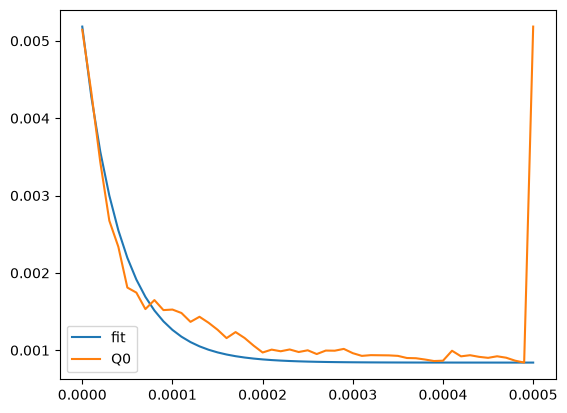

In [228]:
# 46    Parallel T1 ['q2'] ['Relaxation time (s)', 'Voltage I0 (V)', 'Voltage Q0 (V)', 'time_index (#)']
d = hdffiles[44][1]

t_1 = 0.00001

t = d["Relaxation time (s)"]
Q0 = d["Voltage Q0 (V)"]
I0 = d["Voltage I0 (V)"]

Q0_max = Q0.max()
Q0_min = Q0.min()

def model(args):
    return (np.exp(-t/args[0])) * (Q0_max - Q0_min) + Q0_min

def optfunc(args):
    return np.sum((model(args)[:-3] - Q0[:-3])**2)*10000

res = opt.minimize(optfunc, [t_1], method="BFGS", options={"maxiter": 10000, "disp": True})

# plt.plot(t, model([t_1]), label="guess")
plt.plot(t, model(res.x), label="fit")

print("t_1", res.x[0])

plt.plot(d["Relaxation time (s)"], d["Voltage Q0 (V)"], label="Q0")
plt.legend()
# plt.plot(d["Relaxation time (s)"], d["Voltage I0 (V)"])
# data = d.pivot_table(columns="Voltage I0 (V)", index="Voltage Q0 (V)", values="Relaxation time (s)")
# nice_hm(data, hdffiles[46][0], False)

In [230]:
hdffiles[211][1]["state ()"]

0        0
1        0
2        0
3        0
4        0
        ..
19995    1
19996    1
19997    1
19998    1
19999    1
Name: state (), Length: 20000, dtype: int32

Optimization terminated successfully.
         Current function value: 745.000000
         Iterations: 31
         Function evaluations: 78


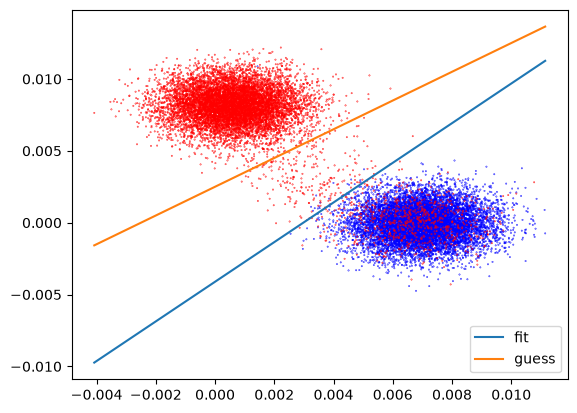

In [246]:
d = hdffiles[211][1]
colors = d["state ()"].map(lambda x: "red" if x == 1 else "blue")

I0 = d["Voltage I0 (V)"]
Q0 = d["Voltage Q0 (V)"]
state = d["state ()"]

def model(args, x):
    slope, intercept = args
    return slope * x + intercept

def optfunc(args):
    pred = model(args, I0) < Q0
    return (state != pred).sum()

guess = [1, 0.0025]

res = opt.minimize(optfunc, guess, method="Nelder-Mead", options={"maxiter": 10000, "disp": True})

I0_min = I0.min()
I0_max = I0.max()

plt.plot([I0_min, I0_max], [model(res.x, I0_min), model(res.x, I0_max)], label="fit")
plt.plot([I0_min, I0_max], [model(guess, I0_min), model(guess, I0_max)], label="guess")
plt.legend()

plt.scatter(d["Voltage I0 (V)"], d["Voltage Q0 (V)"], s=0.1, c=colors)

In [36]:

for attr in hdffiles[200][1]["y1"].attrs:
    print(attr + " - ", hdffiles[200][1]["y1"].attrs[attr])

DIMENSION_LIST -  [array([<HDF5 object reference>], dtype=object)]
_Netcdf4Coordinates -  [0]
_Netcdf4Dimid -  0
_FillValue -  [nan]
name -  Q
long_name -  Voltage Q0
units -  V
batched -  [ True]
batch_size -  [10000]
coordinates -  x0 x1


In [30]:
hdffiles[30][1].keys()

<KeysViewHDF5 ['dim_0', 'x0', 'y0', 'y1']>

In [2]:
datapath = "./Session1Group6b_raw/quantify-data/20260916/"

In [3]:
filepaths = os.listdir(datapath)

In [41]:
resonator = h5py.File(datapath + "/" + filepaths[-7] + "/dataset.hdf5", 'r')

Text(50.83333333333332, 0.5, 'Power')

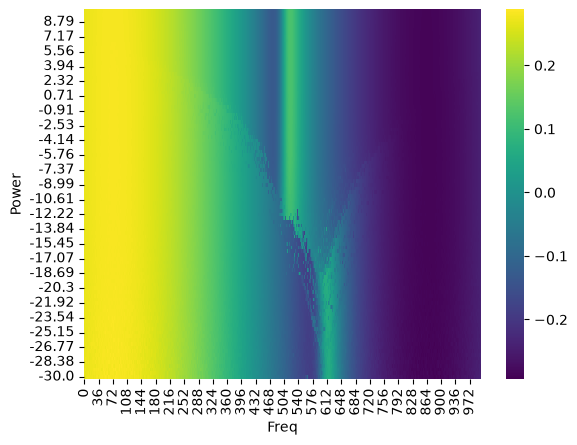

In [42]:
y0 = np.array(resonator["y0"])
y1 = np.array(resonator["y1"])
x0 = np.array(resonator["x0"])
x1 = np.array(resonator["x1"])
dim = np.array(resonator["dim_0"])

df = pd.DataFrame({
    "x": x0,
    "y": x1,
    "val": y0
})

table = df.pivot(index="x", columns="y", values="val")
table.index = np.round(table.index, 2)
sns.heatmap(table, cmap="viridis").invert_yaxis()
plt.xlabel("Freq")
plt.ylabel("Power")